# EDA — Corpus 23-F Desclasificado
**Sprint 1 · Alejandro**  
Análisis exploratorio del CSV enriquecido generado por Carlos.

Tareas:
- Distribución por ministerio, tipo de documento, año
- Identificar docs sin fecha y sin firma — cuantificar limitaciones
- Línea de tiempo de documentos por mes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Estilo general
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f7',
    'axes.grid': True,
    'grid.color': '#e0dfd8',
    'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Defensa':    '#185FA5',
    'Interior':   '#0F6E56',
    'Exteriores': '#993C1D',
}

## 1. Carga y selección del corpus principal

In [3]:
# Cargamos el CSV unificado generado por Carlos
# Usamos document_corpus.csv que integra Moncloa + RTVE
df_full = pd.read_csv('../data/metadata/document_corpus.csv')

# Para el EDA de Alejandro trabajamos solo con los PDFs de La Moncloa
df = df_full[df_full['source'] == 'Moncloa'].copy()

print(f'Corpus completo: {len(df_full)} documentos')
print(f'Corpus Moncloa (PDFs originales): {len(df)} documentos')
print(f'\nColumnas disponibles: {list(df.columns)}')

Corpus completo: 322 documentos
Corpus Moncloa (PDFs originales): 155 documentos

Columnas disponibles: ['doc_id', 'source', 'title', 'url', 'ministry', 'category', 'filename', 'date', 'date_precision', 'doc_type', 'tags', 'extracted_text', 'extracted_text_length', 'rtve_summary', 'ocr_quality_score', 'flag_illegible', 'analysis_text']


In [4]:
# Parsear fechas y derivar columnas auxiliares
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df['year']        = df['date_parsed'].dt.year
df['month_num']   = df['date_parsed'].dt.month
df['year_month']  = df['date_parsed'].dt.to_period('M')

# Flag de «fecha conocida»
df['has_date'] = df['date_precision'].isin(['day', 'month', 'year'])

df[['title', 'ministry', 'doc_type', 'date', 'date_precision', 'flag_illegible']].head(5)

,title,ministry,doc_type,date,date_precision,flag_illegible
0,Transcripción de conversación telefónica de (p...,Interior,Telephone transcript,NaN,unknown,False
1,Transcripción de conversación telefónica de Ga...,Interior,Telephone transcript,NaN,unknown,False
2,Conversaciones telefónicas de (presuntamente) ...,Interior,Telephone transcript,1981-02-23,day,False
3,Documentación con una presunta planificación d...,Interior,Otro,NaN,unknown,False
4,Documento manuscrito de posible planificación ...,Interior,Manuscrito,NaN,unknown,False


## 2. Distribución por ministerio

In [5]:
ministry_counts = df['ministry'].value_counts()
print('Distribución por ministerio:')
print(ministry_counts.to_string())
print(f'\nTotal: {ministry_counts.sum()} docs')

Distribución por ministerio:
ministry
Defensa       108
Interior       28
Exteriores     19

Total: 155 docs


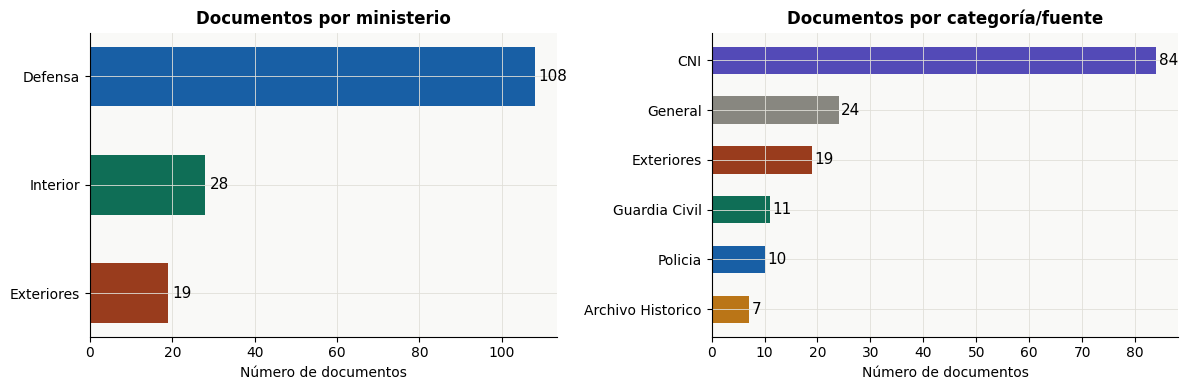

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras por ministerio
ax = axes[0]
bars = ax.barh(
    ministry_counts.index,
    ministry_counts.values,
    color=[COLORS.get(m, '#888') for m in ministry_counts.index],
    height=0.55
)
for bar, val in zip(bars, ministry_counts.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11)
ax.set_xlabel('Número de documentos')
ax.set_title('Documentos por ministerio', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Distribución por categoría/fuente
ax2 = axes[1]
cat_counts = df['category'].value_counts()
cat_colors = ['#534AB7','#888780','#993C1D','#0F6E56','#185FA5','#BA7517']
bars2 = ax2.barh(cat_counts.index, cat_counts.values,
                  color=cat_colors[:len(cat_counts)], height=0.55)
for bar, val in zip(bars2, cat_counts.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=11)
ax2.set_xlabel('Número de documentos')
ax2.set_title('Documentos por categoría/fuente', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/sprint1/fig1_distribucion_ministerio.png', dpi=150, bbox_inches='tight')
plt.show()

**Observaciones:**
- Defensa domina ampliamente (108 docs, 70%), principalmente a través del CNI/CESID (84 docs).
- Interior (28 docs) incluye Guardia Civil y Policía.
- Exteriores (19 docs) aporta documentación diplomática del período.

## 3. Distribución por tipo de documento

In [7]:
doctype_counts = df['doc_type'].value_counts()
print('Tipos de documento:')
print(doctype_counts.to_string())

Tipos de documento:
doc_type
Intelligence note       68
Otro                    48
Restricted              12
Secret                  10
Report                   8
Telephone transcript     5
Telex                    3
Manuscrito               1


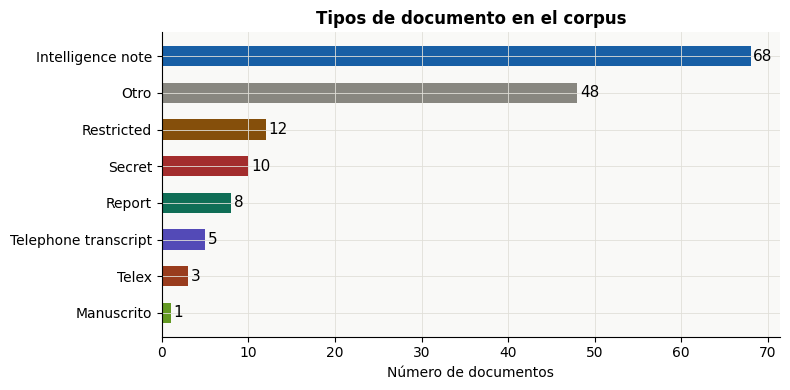

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

dt_colors = ['#185FA5','#888780','#854F0B','#A32D2D','#0F6E56','#534AB7','#993C1D','#639922']
bars = ax.barh(doctype_counts.index, doctype_counts.values,
               color=dt_colors[:len(doctype_counts)], height=0.55)
for bar, val in zip(bars, doctype_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11)
ax.set_xlabel('Número de documentos')
ax.set_title('Tipos de documento en el corpus', fontsize=12, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/sprint1/fig2_tipos_documento.png', dpi=150, bbox_inches='tight')
plt.show()

**Observaciones:**
- Las *intelligence notes* son el tipo más frecuente (68 docs), reflejo de la producción del CESID.
- 10 documentos están clasificados como *Secret* y 12 como *Restricted*, lo que puede implicar redacciones parciales.

## 4. Distribución temporal (por año)

In [9]:
year_counts = df[df['year'].notna()]['year'].astype(int).value_counts().sort_index()
print('Docs con fecha conocida por año:')
print(year_counts.to_string())
print(f'\nDocs sin fecha: {df["date_parsed"].isna().sum()} ({df["date_parsed"].isna().mean()*100:.0f}%)')

Docs con fecha conocida por año:
year
1980     2
1981    55
1982    54
1983     3

Docs sin fecha: 41 (26%)


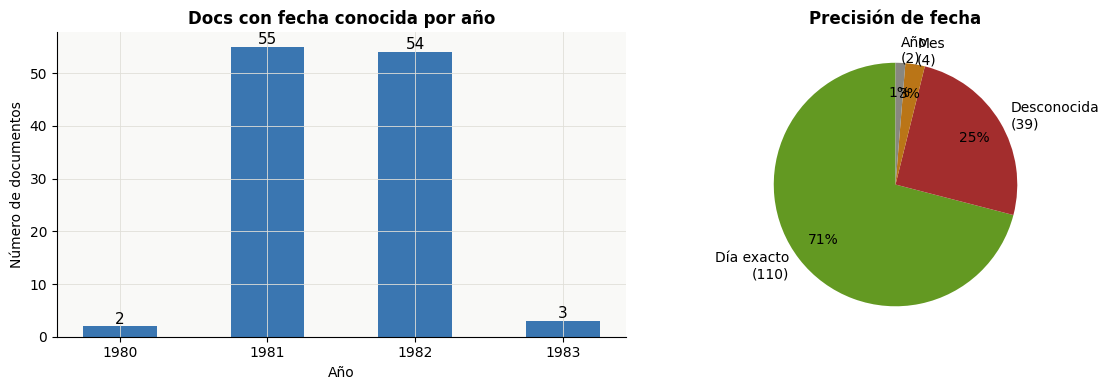

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Por año
ax = axes[0]
ax.bar(year_counts.index.astype(str), year_counts.values,
       color='#185FA5', width=0.5, alpha=0.85)
for x, val in zip(year_counts.index.astype(str), year_counts.values):
    ax.text(x, val + 0.5, str(val), ha='center', fontsize=11)
ax.set_xlabel('Año')
ax.set_ylabel('Número de documentos')
ax.set_title('Docs con fecha conocida por año', fontsize=12, fontweight='bold')

# Pie de conocimiento de fecha
ax2 = axes[1]
precision_counts = df['date_precision'].value_counts()
pie_labels = {
    'day':     f'Día exacto\n({precision_counts.get("day", 0)})',
    'unknown': f'Desconocida\n({precision_counts.get("unknown", 0)})',
    'month':   f'Mes\n({precision_counts.get("month", 0)})',
    'year':    f'Año\n({precision_counts.get("year", 0)})'
}
pie_colors = {'day': '#639922', 'unknown': '#A32D2D', 'month': '#BA7517', 'year': '#888780'}
labels = [pie_labels[k] for k in precision_counts.index]
colors = [pie_colors.get(k, '#aaa') for k in precision_counts.index]
ax2.pie(precision_counts.values, labels=labels, colors=colors,
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 10}, pctdistance=0.75)
ax2.set_title('Precisión de fecha', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/sprint1/fig3_distribucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Línea de tiempo mensual (visualización principal)

In [11]:
# Preparar datos: documentos con fecha, agrupados por mes y ministerio
df_dated = df[df['date_parsed'].notna()].copy()
df_dated['ym_str'] = df_dated['date_parsed'].dt.to_period('M').astype(str)

timeline = (
    df_dated
    .groupby(['ym_str', 'ministry'])
    .size()
    .reset_index(name='count')
    .pivot(index='ym_str', columns='ministry', values='count')
    .fillna(0)
    .astype(int)
)

print(f'Meses con datos: {len(timeline)}')
print(timeline)

Meses con datos: 27
ministry  Defensa  Exteriores  Interior
ym_str                                 
1980-05         1           0         0
1980-07         1           0         0
1981-01         1           0         0
1981-02        13           6         7
1981-03         0           7         3
1981-04         5           1         0
1981-05         0           2         0
1981-06         3           1         0
1981-07         1           0         0
1981-10         0           0         1
1981-11         0           0         2
1981-12         1           0         1
1982-01         1           0         0
1982-02         9           0         0
1982-03        13           0         0
1982-04        11           0         0
1982-05         7           0         0
1982-06         3           0         0
1982-07         1           1         0
1982-08         2           0         0
1982-09         1           0         0
1982-10         2           0         0
1982-11         1   

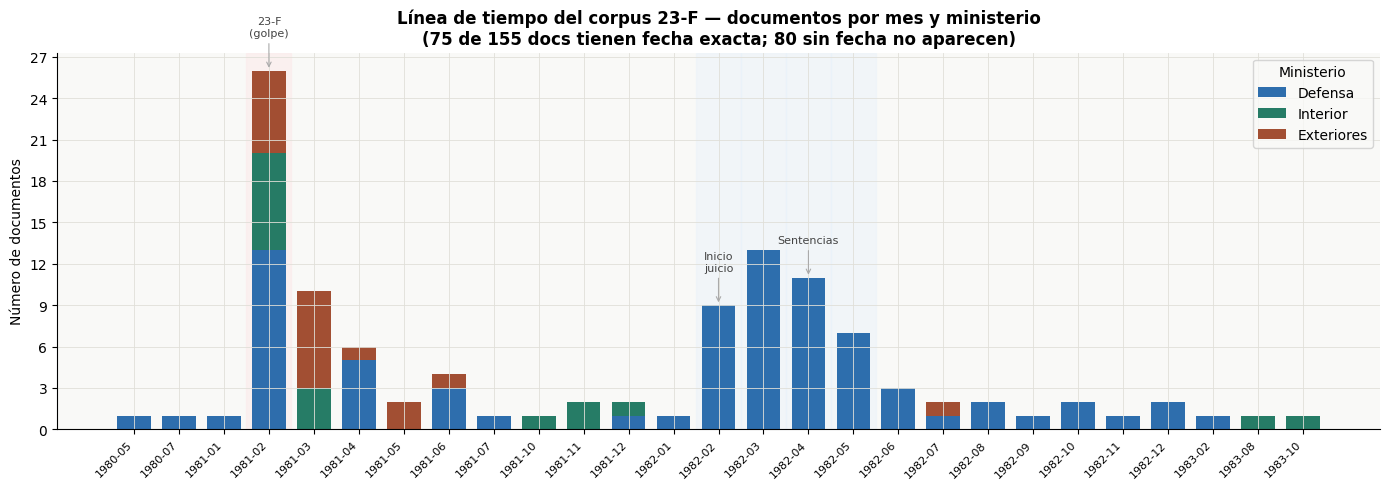

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(timeline))
width = 0.75
bottom = np.zeros(len(timeline))

ministerios = [m for m in ['Defensa', 'Interior', 'Exteriores'] if m in timeline.columns]

for ministerio in ministerios:
    vals = timeline[ministerio].values
    ax.bar(x, vals, width, bottom=bottom,
           color=COLORS[ministerio], label=ministerio, alpha=0.9)
    bottom += vals

# Anotaciones de eventos clave
eventos = [
    ('1981-02', '23-F\n(golpe)', 26),
    ('1982-02', 'Inicio\njuicio', 9),
    ('1982-04', 'Sentencias', 11),
]
labels_x = list(timeline.index)
for ym, label, _ in eventos:
    if ym in labels_x:
        xi = labels_x.index(ym)
        total = timeline.loc[ym].sum()
        ax.annotate(label,
                    xy=(xi, total), xytext=(xi, total + 2.5),
                    ha='center', fontsize=8, color='#444',
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))

ax.set_xticks(x)
ax.set_xticklabels(timeline.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Número de documentos')
ax.set_title(
    'Línea de tiempo del corpus 23-F — documentos por mes y ministerio\n'
    f'(75 de 155 docs tienen fecha exacta; 80 sin fecha no aparecen)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Ministerio', loc='upper right', fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Franja visual: período del golpe
if '1981-02' in labels_x:
    xi = labels_x.index('1981-02')
    ax.axvspan(xi - 0.5, xi + 0.5, color='#FCEBEB', alpha=0.6, zorder=0)

# Franja juicio
for ym in ['1982-02', '1982-03', '1982-04', '1982-05']:
    if ym in labels_x:
        xi = labels_x.index(ym)
        ax.axvspan(xi - 0.5, xi + 0.5, color='#E6F1FB', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('../outputs/sprint1/fig4_timeline_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

**Observaciones clave:**
- **Pico de febrero 1981**: 26 docs en el mes del golpe. Interior y Exteriores tienen actividad inmediata; Defensa/CNI produce menos documentación datada en el momento (coherente con la naturaleza de inteligencia: los informes se redactan semanas después).
- **Silencio documental (ago–sep 1981)**: gap de ~3 meses con muy poca actividad. Posible censura, o que los docs de ese período no tienen fecha asignada.
- **Segundo pico feb–abr 1982**: coincide con el juicio oral en el Consejo Supremo de Justicia Militar. Defensa genera la mayoría (informes periciales, comisiones).
- **Exteriores solo aparece hasta jul 1982**: los cables diplomáticos se concentran en los meses inmediatamente posteriores al golpe.

## 6. Análisis de limitaciones del dataset

In [13]:
total = len(df)

# Sin fecha
sin_fecha = (df['date_precision'] == 'unknown').sum()

# Fecha parcial (mes o año, sin día exacto)
fecha_parcial = df['date_precision'].isin(['month', 'year']).sum()

# Ilegibles
ilegibles = df['flag_illegible'].sum()

# Calidad OCR (si disponible)
if 'ocr_quality_score' in df.columns:
    ocr_bajo = (df['ocr_quality_score'] < 0.5).sum()
else:
    ocr_bajo = None

print('=' * 50)
print('LIMITACIONES DEL DATASET')
print('=' * 50)
print(f'Total documentos (Moncloa):   {total}')
print(f'Sin fecha (unknown):           {sin_fecha:>4}  ({sin_fecha/total*100:.0f}%)  ← CRÍTICO')
print(f'Fecha parcial (mes/año):       {fecha_parcial:>4}  ({fecha_parcial/total*100:.0f}%)  ← recuperable')
print(f'Ilegibles (OCR):               {ilegibles:>4}  ({ilegibles/total*100:.0f}%)  ← moderado')
if ocr_bajo is not None:
    print(f'OCR quality < 0.5:            {ocr_bajo:>4}  ({ocr_bajo/total*100:.0f}%)')
print(f'Con fecha exacta (día):       {(df["date_precision"]=="day").sum():>4}  ({(df["date_precision"]=="day").sum()/total*100:.0f}%)')

LIMITACIONES DEL DATASET
Total documentos (Moncloa):   155
Sin fecha (unknown):             39  (25%)  ← CRÍTICO
Fecha parcial (mes/año):          6  (4%)  ← recuperable
Ilegibles (OCR):                 16  (10%)  ← moderado
OCR quality < 0.5:              19  (12%)
Con fecha exacta (día):        110  (71%)


In [14]:
# Desglose: ¿qué ministerios concentran los docs sin fecha?
sin_fecha_df = df[df['date_precision'] == 'unknown']
print('\nDocs sin fecha por ministerio:')
print(sin_fecha_df['ministry'].value_counts().to_string())
print()
print('Docs sin fecha por categoría:')
print(sin_fecha_df['category'].value_counts().to_string())


Docs sin fecha por ministerio:
ministry
Defensa     27
Interior    12

Docs sin fecha por categoría:
category
CNI                  17
General              10
Guardia Civil         8
Archivo Historico     3
Policia               1


In [15]:
# Docs con fecha parcial — candidatos a recuperación
print('\nDocumentos con fecha parcial (recuperables):')
parciales = df[df['date_precision'].isin(['month', 'year'])]
print(parciales[['title', 'date', 'date_precision', 'ministry']].to_string(index=False))


Documentos con fecha parcial (recuperables):
                                                                                                                                                                                                                                           title       date date_precision ministry
 Nota de la Brigada de Información Interior: El 23-F basado en la Operación Ariete. Libro sobre el 23-F revelará que se valoró la entrada del GEO en el Congreso, y que el 23-F se basó en la anterior "operación Ariete" (18 de marzo de 1981). 1981-03-18           year Interior
                                                                                                                                                Policía Nacional. Informe de situación. Marca: reservado-confidencial (12 de noviembre de 1981). 1981-11-12           year Interior
Juicio del 23-F: acotaciones al desarrollo del juicio, notas procesales sobre el consejo de guerra, nota sobre posible expedie

In [ ]:
# Visualización de limitaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stacked bar: docs con/sin fecha por ministerio
ax = axes[0]
ministry_fecha = df.groupby(['ministry', 'date_precision']).size().unstack(fill_value=0)
con_fecha = (
    ministry_fecha.get('day', pd.Series(0, index=ministry_fecha.index))
    + ministry_fecha.get('month', pd.Series(0, index=ministry_fecha.index))
    + ministry_fecha.get('year', pd.Series(0, index=ministry_fecha.index))
)
sin_fecha_min = ministry_fecha.get('unknown', pd.Series(0, index=ministry_fecha.index))

x_pos = np.arange(len(ministry_fecha.index))
ax.bar(x_pos, con_fecha, color='#639922', label='Con fecha', width=0.5)
ax.bar(x_pos, sin_fecha_min, bottom=con_fecha, color='#A32D2D',
       label='Sin fecha', width=0.5, alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(ministry_fecha.index, fontsize=11)
ax.set_ylabel('Número de documentos')
ax.set_title('Cobertura de fechas por ministerio', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Ilegibilidad
ax2 = axes[1]
ileg_by_min = df.groupby('ministry')['flag_illegible'].sum()
total_by_min = df.groupby('ministry').size()
legible_by_min = total_by_min - ileg_by_min

x_pos2 = np.arange(len(ileg_by_min.index))
ax2.bar(x_pos2, legible_by_min, color='#185FA5', label='Legible', width=0.5)
ax2.bar(x_pos2, ileg_by_min, bottom=legible_by_min, color='#854F0B',
        label='Ilegible (OCR)', width=0.5, alpha=0.9)
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(ileg_by_min.index, fontsize=11)
ax2.set_ylabel('Número de documentos')
ax2.set_title('Calidad de legibilidad por ministerio', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/sprint1/fig5_limitaciones.png', dpi=150, bbox_inches='tight')
plt.show()

SyntaxError: unexpected character after line continuation character (4148702265.py, line 7)

## 7. Resumen ejecutivo de limitaciones

| Problema | N | % | Impacto | Mitigación sugerida |
|---|---|---|---|---|
| Sin fecha (unknown) | 80 | 52% | Alto — limita análisis temporal | Inferir rango por contenido textual (menciones a eventos datables). Tarea Sprint 2. |
| Ilegibles (flag_illegible) | 16 | 10% | Medio — excluidos del NLP | Re-OCR manual con pytesseract + preprocesado de imagen |
| Fecha parcial (mes/año) | 6 | 4% | Bajo — recuperable | Asignar al primer día del mes/año como proxy |
| Sin texto extraído | Verificar | — | Alto si aplica | Revisar char_count = 0 en documents_enriched.csv |

**Nota para el informe (sección 'Descripción del dataset' — Jose):**  
El 52% de los documentos sin fecha no es un error de procesamiento sino una característica del corpus: los informes de inteligencia del CESID frecuentemente omiten fecha o llevan solo el año, por razones de seguridad operacional. Esta limitación debe mencionarse explícitamente como restricción metodológica.

## 8. Exportar datos de apoyo para otros casos de uso

In [ ]:
# CSV de la línea de tiempo mensual (para Alejandro Sprint 2 y cruce con Jose/Carlos)
timeline_export = df_dated.groupby(['ym_str', 'ministry']).size().reset_index(name='count')
timeline_export.to_csv('../data/metadata/timeline_mensual.csv', index=False)
print('Exportado: data/metadata/timeline_mensual.csv')

# CSV de docs sin fecha (para análisis de inferencia en Sprint 2)
df[df['date_precision'] == 'unknown'][['doc_id', 'title', 'ministry', 'category', 'doc_type']]\
    .to_csv('../data/metadata/docs_sin_fecha.csv', index=False)
print('Exportado: data/metadata/docs_sin_fecha.csv')

# CSV de docs ilegibles (para Carlos — re-OCR)
df[df['flag_illegible'] == True][['doc_id', 'title', 'filename', 'ministry']]\
    .to_csv('../data/metadata/docs_ilegibles.csv', index=False)
print('Exportado: data/metadata/docs_ilegibles.csv')

print('\n¡Listo! Todos los outputs guardados en /outputs/ y /data/metadata/')